In [1]:
# ============================================
# PHASE 2 — ANALYSIS & VISUALIZATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set the visual style for all charts
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

# Load our clean datasets
brent = pd.read_csv('brent_clean.csv', parse_dates=['date'])
iran = pd.read_csv('iran_clean.csv')
events = pd.read_csv('events_clean.csv', parse_dates=['date'])
yearly = pd.read_csv('yearly_avg_prices.csv')
iran_vs_price = pd.read_csv('iran_vs_price.csv')

print("✅ All datasets loaded!")
print(f"   → Brent prices: {len(brent)} rows")
print(f"   → Iran production: {len(iran)} rows")
print(f"   → Events: {len(events)} rows")
print("\n🎨 Ready to build charts!")

✅ All datasets loaded!
   → Brent prices: 2345 rows
   → Iran production: 9 rows
   → Events: 14 rows

🎨 Ready to build charts!


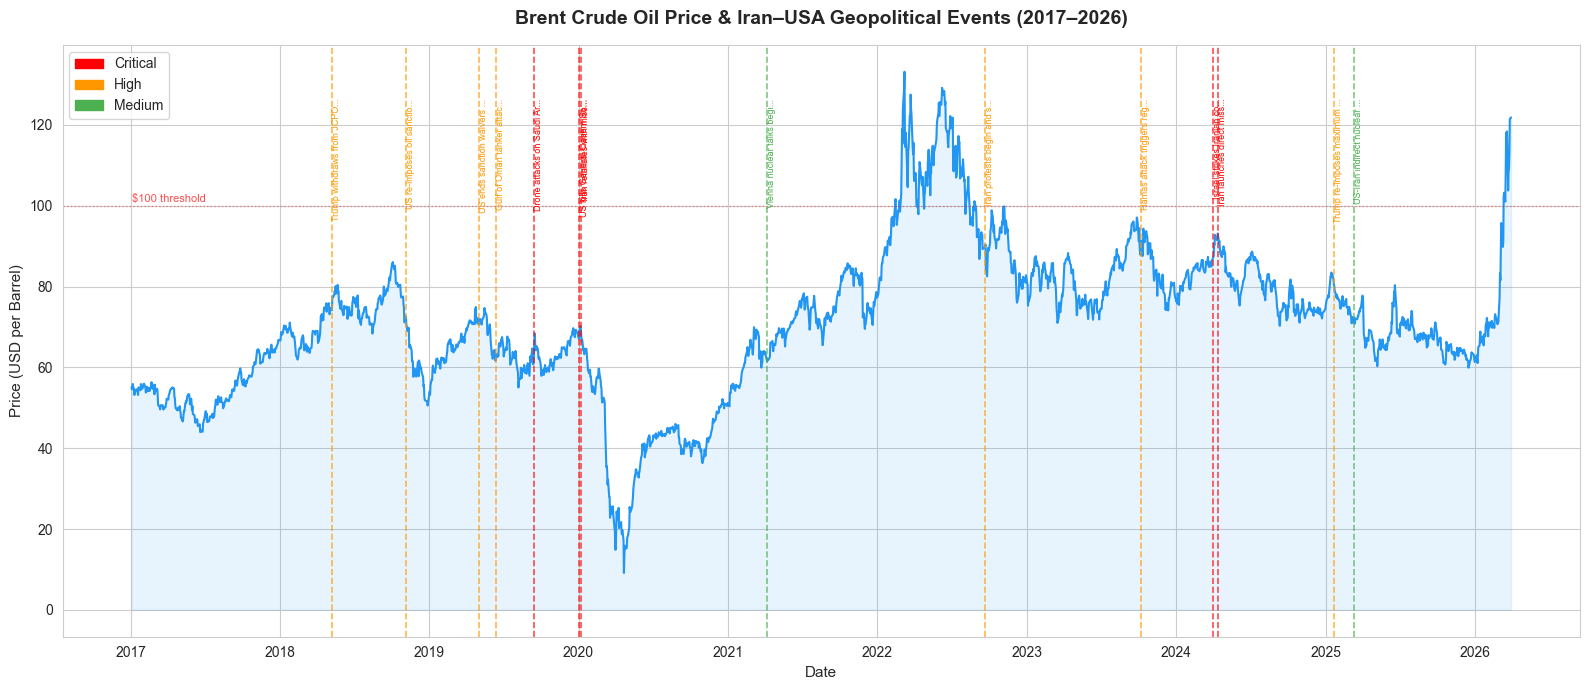

✅ Chart 1 saved as chart1_price_timeline.png


In [3]:
# ============================================
# CHART 1 — Oil Price Timeline + Events
# ============================================

fig, ax = plt.subplots(figsize=(16, 7))

# Plot the oil price line
ax.plot(brent['date'], brent['price'], 
        color='#2196F3', linewidth=1.5, label='Brent Crude Price')

# Fill under the line for visual impact
ax.fill_between(brent['date'], brent['price'], 
                alpha=0.1, color='#2196F3')

# Color code by severity
colors = {'Critical': '#FF0000', 'High': '#FF9800', 'Medium': '#4CAF50'}

for _, row in events.iterrows():
    color = colors[row['severity']]
    # Draw vertical line at each event
    ax.axvline(x=row['date'], color=color, 
               linestyle='--', alpha=0.7, linewidth=1.2)
    # Add event label
    ax.text(row['date'], brent['price'].max() * 0.95, 
            row['event'][:25] + '...', 
            rotation=90, fontsize=6.5, color=color,
            verticalalignment='top')

# Legend for severity colors
patches = [mpatches.Patch(color=c, label=s) 
           for s, c in colors.items()]
ax.legend(handles=patches, loc='upper left', fontsize=10)

# Labels and title
ax.set_title('Brent Crude Oil Price & Iran–USA Geopolitical Events (2017–2026)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD per Barrel)', fontsize=11)

# Highlight key price zones
ax.axhline(y=100, color='red', linestyle=':', alpha=0.4, linewidth=1)
ax.text(brent['date'].min(), 101, '$100 threshold', 
        fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig('chart1_price_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 1 saved as chart1_price_timeline.png")

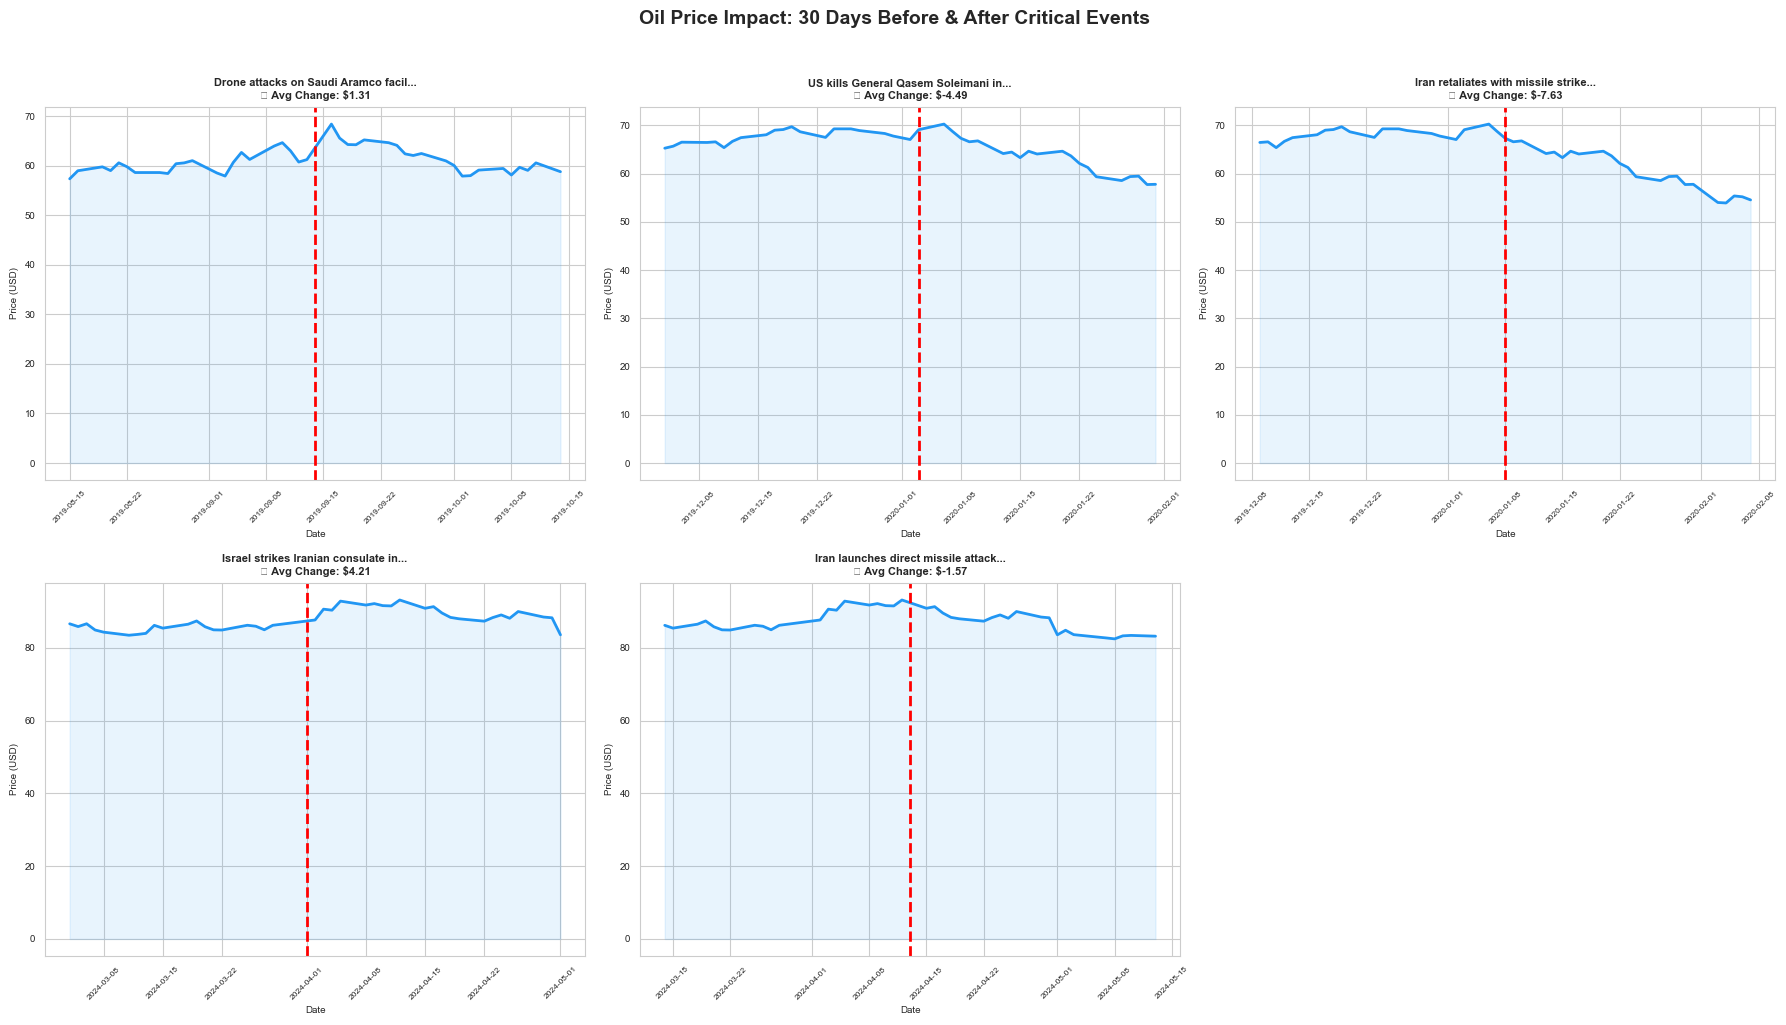

✅ Chart 2 saved as chart2_critical_events.png


In [5]:
# ============================================
# CHART 2 — Price Impact Around Critical Events
# ============================================

# Filter only Critical events
critical_events = events[events['severity'] == 'Critical'].reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (_, event) in enumerate(critical_events.iterrows()):
    ax = axes[i]
    
    # Get 30 days before and after the event
    start = event['date'] - pd.Timedelta(days=30)
    end = event['date'] + pd.Timedelta(days=30)
    mask = (brent['date'] >= start) & (brent['date'] <= end)
    window = brent[mask].copy()
    
    if len(window) == 0:
        continue
    
    # Plot price line
    ax.plot(window['date'], window['price'], 
            color='#2196F3', linewidth=2)
    ax.fill_between(window['date'], window['price'], 
                    alpha=0.1, color='#2196F3')
    
    # Mark the event date
    ax.axvline(x=event['date'], color='red', 
               linestyle='--', linewidth=2, label='Event Date')
    
    # Calculate price change
    before = window[window['date'] <= event['date']]['price'].mean()
    after = window[window['date'] > event['date']]['price'].mean()
    change = round(after - before, 2)
    arrow = "📈" if change > 0 else "📉"
    
    # Title and labels
    ax.set_title(f"{event['event'][:35]}...\n{arrow} Avg Change: ${change}", 
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('Date', fontsize=7)
    ax.set_ylabel('Price (USD)', fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', labelsize=7)

# Hide unused subplot
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Oil Price Impact: 30 Days Before & After Critical Events', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_critical_events.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 2 saved as chart2_critical_events.png")

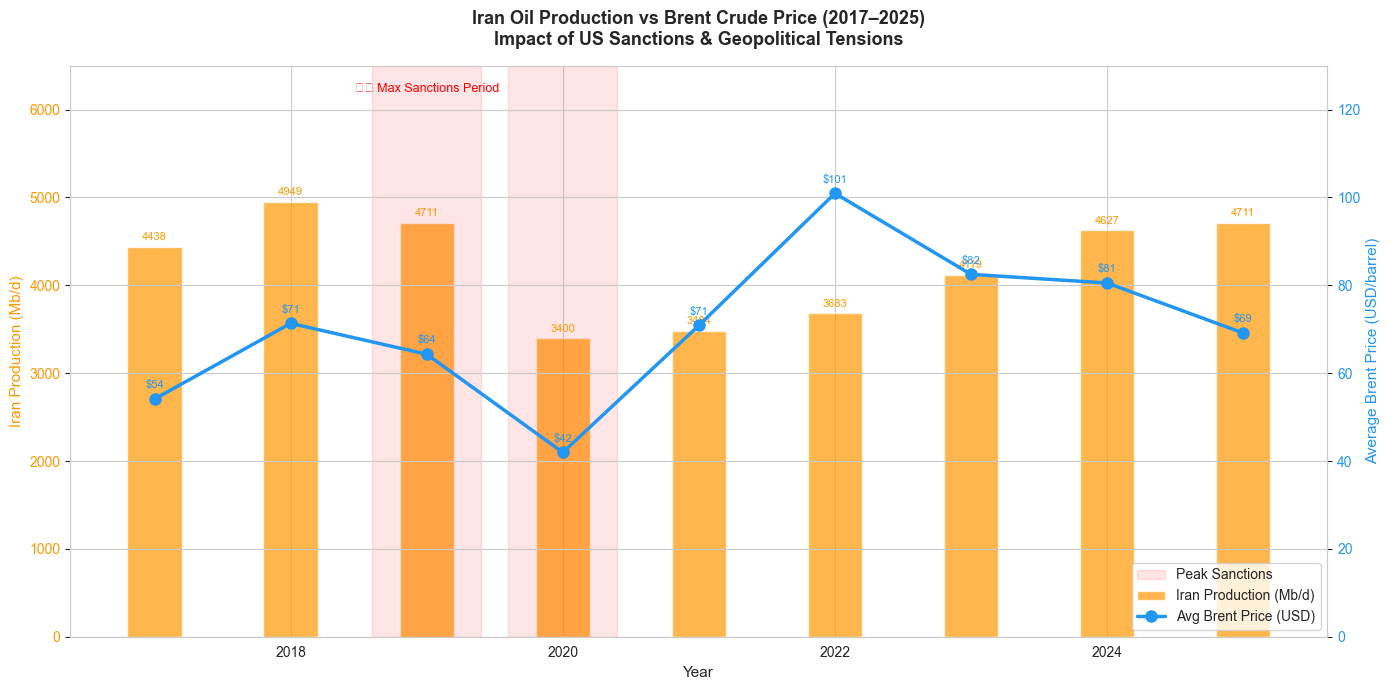

✅ Chart 3 saved as chart3_iran_vs_price.png


In [6]:
# ============================================
# CHART 3 — Iran Production vs Brent Price
# ============================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Left axis — Iran Production (bars) ---
bars = ax1.bar(iran_vs_price['year'], 
               iran_vs_price['iran_production'],
               color='#FF9800', alpha=0.7, width=0.4,
               label='Iran Production (Mb/d)')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Iran Production (Mb/d)', fontsize=11, color='#FF9800')
ax1.tick_params(axis='y', labelcolor='#FF9800')
ax1.set_ylim(0, 6500)

# --- Right axis — Brent Price (line) ---
ax2 = ax1.twinx()
ax2.plot(iran_vs_price['year'], 
         iran_vs_price['avg_brent_price'],
         color='#2196F3', linewidth=2.5, 
         marker='o', markersize=8,
         label='Avg Brent Price (USD)')
ax2.set_ylabel('Average Brent Price (USD/barrel)', 
               fontsize=11, color='#2196F3')
ax2.tick_params(axis='y', labelcolor='#2196F3')
ax2.set_ylim(0, 130)

# Add value labels on bars
for bar, val in zip(bars, iran_vs_price['iran_production']):
    ax1.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 50,
             f'{val:.0f}', ha='center', 
             va='bottom', fontsize=8, color='#FF9800')

# Add value labels on line
for x, y in zip(iran_vs_price['year'], iran_vs_price['avg_brent_price']):
    ax2.text(x, y + 2, f'${y:.0f}', ha='center', 
             va='bottom', fontsize=8, color='#2196F3')

# Mark sanction years
ax1.axvspan(2018.6, 2019.4, alpha=0.1, color='red', label='Peak Sanctions')
ax1.axvspan(2019.6, 2020.4, alpha=0.1, color='red')
ax1.text(2019, 6200, '⚠️ Max Sanctions Period', 
         fontsize=9, color='red', ha='center')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='lower right', fontsize=10)

plt.title('Iran Oil Production vs Brent Crude Price (2017–2025)\nImpact of US Sanctions & Geopolitical Tensions', 
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart3_iran_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 3 saved as chart3_iran_vs_price.png")

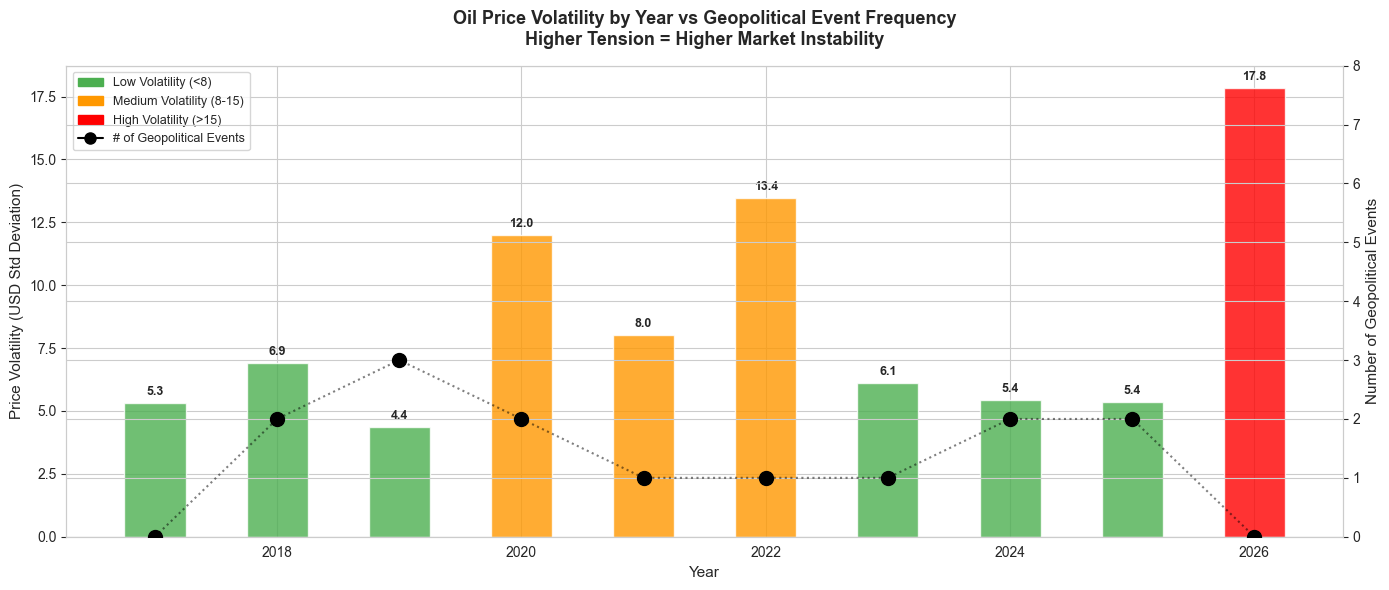

✅ Chart 4 saved as chart4_volatility.png


In [7]:
# ============================================
# CHART 4 — Price Volatility by Year
# ============================================

# Calculate standard deviation per year = volatility
brent['year'] = brent['date'].dt.year
volatility = brent.groupby('year')['price'].std().reset_index()
volatility.columns = ['year', 'volatility']

# Count events per year
events['year'] = events['date'].dt.year
event_counts = events.groupby('year').size().reset_index()
event_counts.columns = ['year', 'event_count']

# Merge
vol_events = volatility.merge(event_counts, on='year', how='left')
vol_events['event_count'] = vol_events['event_count'].fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Color bars by volatility level
colors_vol = ['#4CAF50' if v < 8 else '#FF9800' if v < 15 else '#FF0000' 
              for v in vol_events['volatility']]

bars = ax1.bar(vol_events['year'], vol_events['volatility'],
               color=colors_vol, alpha=0.8, width=0.5,
               label='Price Volatility (Std Dev)')

# Add value labels on bars
for bar, val in zip(bars, vol_events['volatility']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}', ha='center',
             va='bottom', fontsize=9, fontweight='bold')

# Right axis — event count dots
ax2 = ax1.twinx()
ax2.scatter(vol_events['year'], vol_events['event_count'],
            color='black', s=100, zorder=5, label='# of Events')
ax2.plot(vol_events['year'], vol_events['event_count'],
         color='black', linestyle=':', alpha=0.5)
ax2.set_ylabel('Number of Geopolitical Events', fontsize=11)
ax2.set_ylim(0, 8)

# Labels
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Price Volatility (USD Std Deviation)', fontsize=11)

# Legend
green = mpatches.Patch(color='#4CAF50', label='Low Volatility (<8)')
orange = mpatches.Patch(color='#FF9800', label='Medium Volatility (8-15)')
red = mpatches.Patch(color='#FF0000', label='High Volatility (>15)')
dot = plt.Line2D([0], [0], marker='o', color='black', 
                  label='# of Geopolitical Events', markersize=8)
ax1.legend(handles=[green, orange, red, dot], 
           loc='upper left', fontsize=9)

plt.title('Oil Price Volatility by Year vs Geopolitical Event Frequency\nHigher Tension = Higher Market Instability',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart4_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 4 saved as chart4_volatility.png")

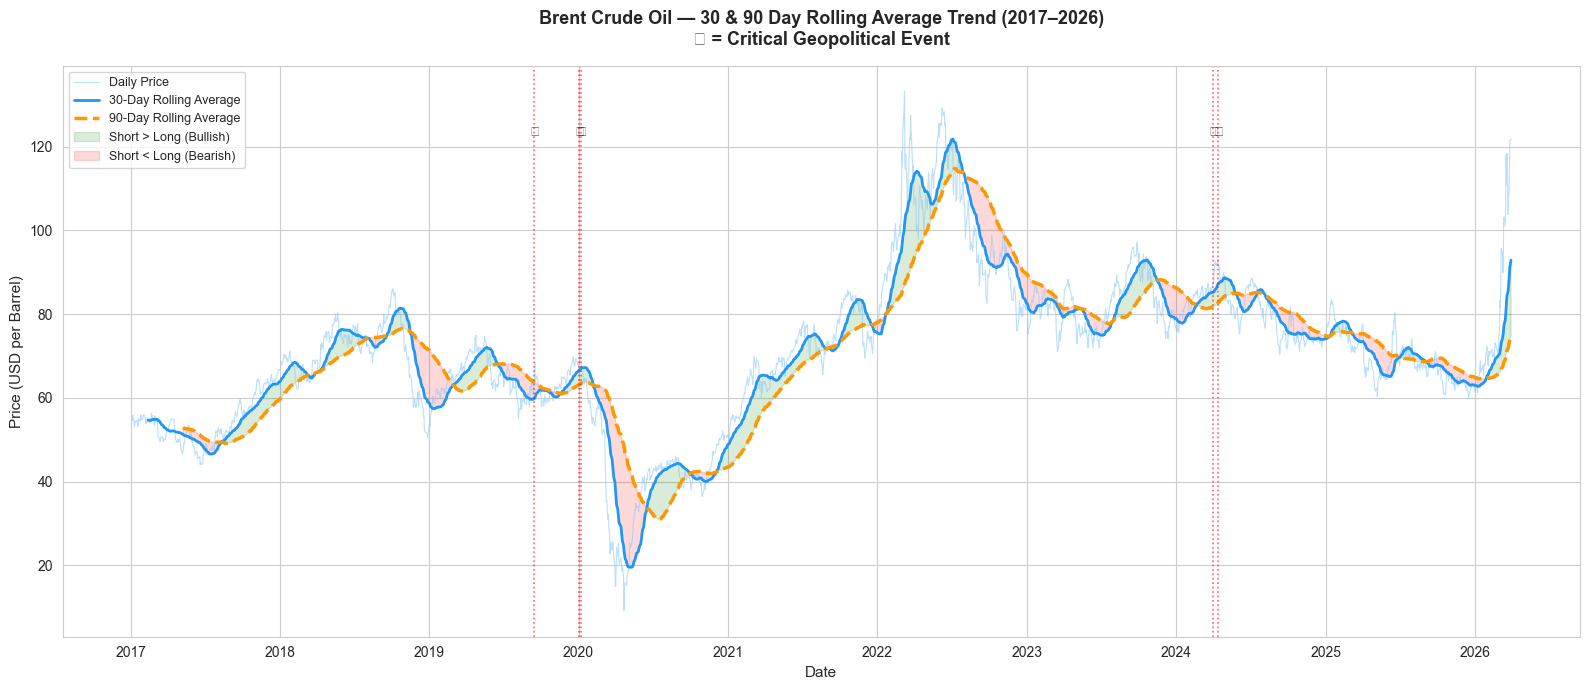

✅ Chart 5 saved as chart5_rolling_average.png


In [8]:
# ============================================
# CHART 5 — 30-Day Rolling Average Trend
# ============================================

# Calculate rolling averages
brent['roll_30'] = brent['price'].rolling(window=30).mean()
brent['roll_90'] = brent['price'].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(16, 7))

# Raw price — light and thin
ax.plot(brent['date'], brent['price'],
        color='#90CAF9', linewidth=0.8,
        alpha=0.6, label='Daily Price')

# 30-day rolling average
ax.plot(brent['date'], brent['roll_30'],
        color='#2196F3', linewidth=2,
        label='30-Day Rolling Average')

# 90-day rolling average
ax.plot(brent['date'], brent['roll_90'],
        color='#FF9800', linewidth=2.5,
        linestyle='--', label='90-Day Rolling Average')

# Shade the difference between 30 and 90 day
ax.fill_between(brent['date'], brent['roll_30'], brent['roll_90'],
                where=brent['roll_30'] > brent['roll_90'],
                alpha=0.15, color='green', label='Short > Long (Bullish)')
ax.fill_between(brent['date'], brent['roll_30'], brent['roll_90'],
                where=brent['roll_30'] < brent['roll_90'],
                alpha=0.15, color='red', label='Short < Long (Bearish)')

# Mark Critical events
critical = events[events['severity'] == 'Critical']
for _, row in critical.iterrows():
    ax.axvline(x=row['date'], color='red',
               linestyle=':', alpha=0.6, linewidth=1.2)
    ax.text(row['date'], brent['price'].max() * 0.92,
            '⚡', fontsize=10, ha='center')

# Labels
ax.set_title('Brent Crude Oil — 30 & 90 Day Rolling Average Trend (2017–2026)\n⚡ = Critical Geopolitical Event',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD per Barrel)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart5_rolling_average.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 5 saved as chart5_rolling_average.png")

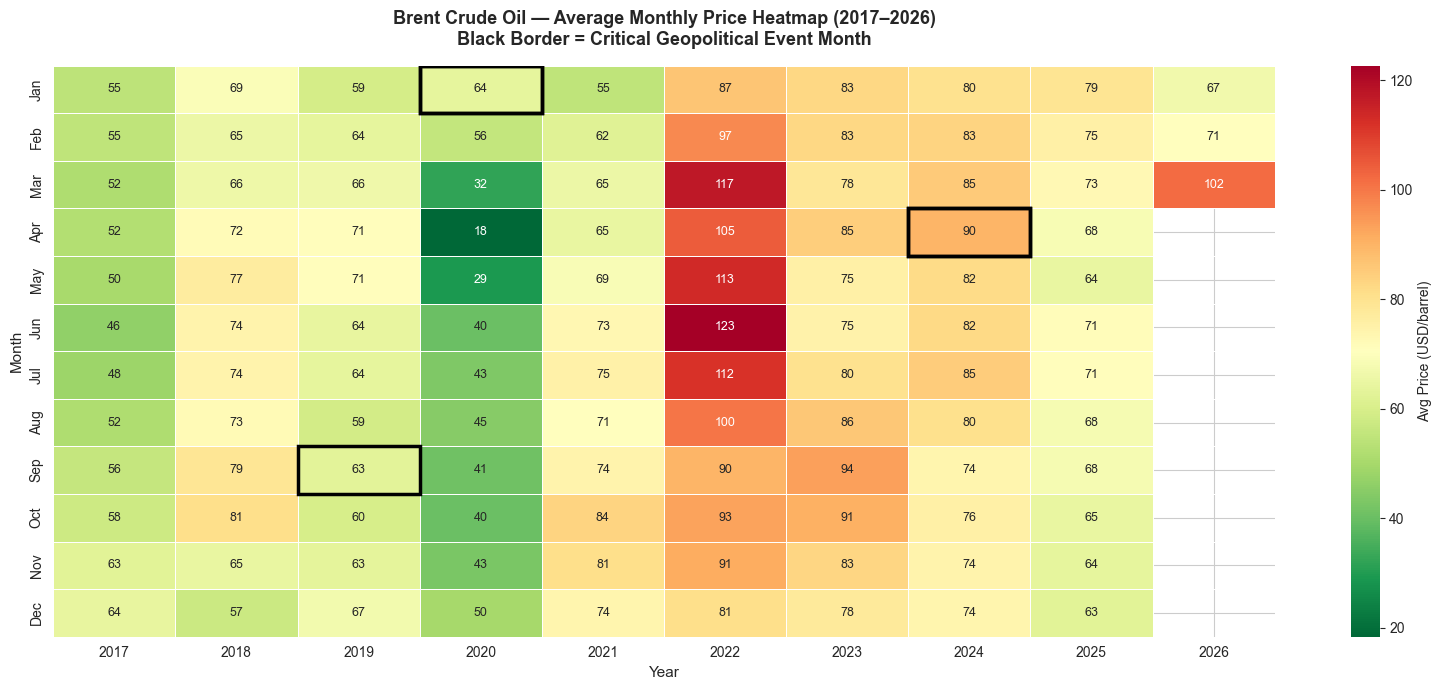

✅ Chart 6 saved as chart6_heatmap.png


In [9]:
# ============================================
# CHART 6 — Monthly Price Heatmap
# ============================================

# Create month and year columns
brent['month'] = brent['date'].dt.month
brent['year'] = brent['date'].dt.year

# Pivot to create heatmap matrix
heatmap_data = brent.pivot_table(
    values='price',
    index='month',
    columns='year',
    aggfunc='mean'
)

# Replace month numbers with names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.index = month_names

fig, ax = plt.subplots(figsize=(16, 7))

# Draw heatmap
sns.heatmap(heatmap_data,
            annot=True,
            fmt='.0f',
            cmap='RdYlGn_r',
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Avg Price (USD/barrel)'},
            annot_kws={'size': 9})

# Mark cells where Critical events happened
critical = events[events['severity'] == 'Critical']
for _, row in critical.iterrows():
    month_idx = row['date'].month - 1
    year = row['date'].year
    if year in heatmap_data.columns:
        col_idx = list(heatmap_data.columns).index(year)
        ax.add_patch(plt.Rectangle(
            (col_idx, month_idx), 1, 1,
            fill=False, edgecolor='black',
            lw=2.5, label='Critical Event'
        ))

# Title and labels
ax.set_title('Brent Crude Oil — Average Monthly Price Heatmap (2017–2026)\nBlack Border = Critical Geopolitical Event Month',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Month', fontsize=11)

plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 6 saved as chart6_heatmap.png")

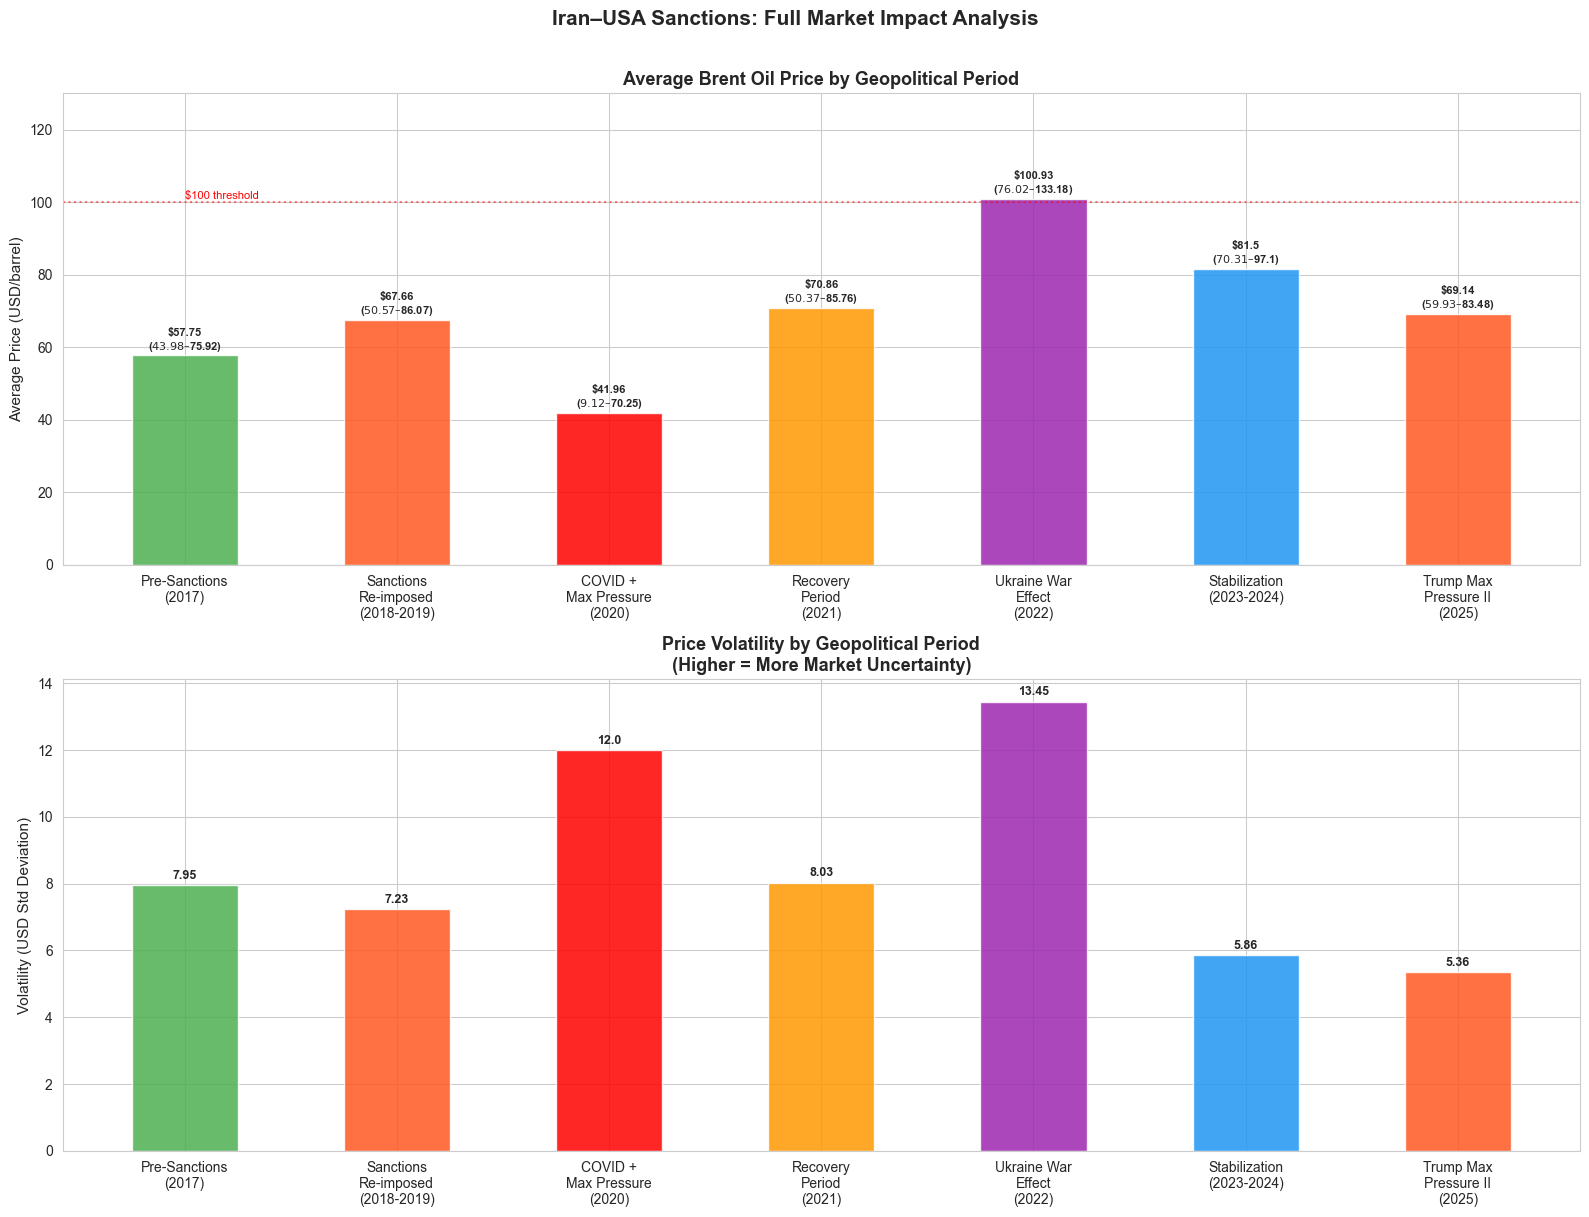

✅ Chart 7 saved as chart7_sanctions_impact.png


In [10]:
# ============================================
# CHART 7 — Sanctions Impact Comparison
# ============================================

# Define key sanctions periods
periods = {
    'Pre-Sanctions\n(2017)': ('2017-01-01', '2018-05-07'),
    'Sanctions\nRe-imposed\n(2018-2019)': ('2018-05-08', '2019-12-31'),
    'COVID +\nMax Pressure\n(2020)': ('2020-01-01', '2020-12-31'),
    'Recovery\nPeriod\n(2021)': ('2021-01-01', '2021-12-31'),
    'Ukraine War\nEffect\n(2022)': ('2022-01-01', '2022-12-31'),
    'Stabilization\n(2023-2024)': ('2023-01-01', '2024-12-31'),
    'Trump Max\nPressure II\n(2025)': ('2025-01-01', '2025-12-31'),
}

# Calculate avg price and volatility for each period
period_stats = []
for label, (start, end) in periods.items():
    mask = (brent['date'] >= start) & (brent['date'] <= end)
    subset = brent[mask]
    if len(subset) > 0:
        period_stats.append({
            'period': label,
            'avg_price': round(subset['price'].mean(), 2),
            'volatility': round(subset['price'].std(), 2),
            'min_price': round(subset['price'].min(), 2),
            'max_price': round(subset['price'].max(), 2)
        })

stats_df = pd.DataFrame(period_stats)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# --- Top chart: Average price per period ---
colors_bar = ['#4CAF50', '#FF5722', '#FF0000',
              '#FF9800', '#9C27B0', '#2196F3', '#FF5722']
bars = ax1.bar(stats_df['period'], stats_df['avg_price'],
               color=colors_bar, alpha=0.85, width=0.5)

# Add value labels
for bar, val, mn, mx in zip(bars, stats_df['avg_price'],
                             stats_df['min_price'], stats_df['max_price']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'${val}\n(${mn}–${mx})',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_title('Average Brent Oil Price by Geopolitical Period',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Price (USD/barrel)', fontsize=11)
ax1.set_ylim(0, 130)
ax1.axhline(y=100, color='red', linestyle=':', alpha=0.5)
ax1.text(0, 101, '$100 threshold', fontsize=8, color='red')

# --- Bottom chart: Volatility per period ---
bars2 = ax2.bar(stats_df['period'], stats_df['volatility'],
                color=colors_bar, alpha=0.85, width=0.5)

for bar, val in zip(bars2, stats_df['volatility']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val}', ha='center',
             va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Price Volatility by Geopolitical Period\n(Higher = More Market Uncertainty)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Volatility (USD Std Deviation)', fontsize=11)

plt.suptitle('Iran–USA Sanctions: Full Market Impact Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart7_sanctions_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 7 saved as chart7_sanctions_impact.png")

In [11]:
# ============================================
# PHASE 2 WRAP UP — SAVE INSIGHTS SUMMARY
# ============================================

summary = {
    'metric': [
        'Total daily price records analyzed',
        'Date range covered',
        'Geopolitical events tracked',
        'Critical events',
        'Highest ever oil price in period',
        'Lowest ever oil price in period',
        'Year with highest avg price',
        'Year with lowest avg price',
        'Year with highest volatility',
        'Iran production peak year',
        'Iran production lowest year',
    ],
    'value': [
        len(brent),
        f"{brent['date'].min().date()} to {brent['date'].max().date()}",
        len(events),
        len(events[events['severity'] == 'Critical']),
        f"${brent['price'].max()} ({brent.loc[brent['price'].idxmax(), 'date'].date()})",
        f"${brent['price'].min()} ({brent.loc[brent['price'].idxmin(), 'date'].date()})",
        f"{yearly.loc[yearly['avg_price'].idxmax(), 'year']} (${yearly['avg_price'].max()})",
        f"{yearly.loc[yearly['avg_price'].idxmin(), 'year']} (${yearly['avg_price'].min()})",
        f"{volatility.loc[volatility['volatility'].idxmax(), 'year']}",
        f"{iran.loc[iran['production_mbd'].idxmax(), 'year']} ({iran['production_mbd'].max():.0f} Mb/d)",
        f"{iran.loc[iran['production_mbd'].idxmin(), 'year']} ({iran['production_mbd'].min():.0f} Mb/d)",
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv('project_summary.csv', index=False)

print("=" * 55)
print("📊 PROJECT SUMMARY — IRAN-USA OIL MARKET ANALYSIS")
print("=" * 55)
for _, row in summary_df.iterrows():
    print(f"  {row['metric']:<40} {row['value']}")

print("\n✅ Summary saved as project_summary.csv")
print("\n📁 Phase 2 Charts Created:")
charts = [
    'chart1_price_timeline.png',
    'chart2_critical_events.png',
    'chart3_iran_vs_price.png',
    'chart4_volatility.png',
    'chart5_rolling_average.png',
    'chart6_heatmap.png',
    'chart7_sanctions_impact.png'
]
for c in charts:
    print(f"   → {c}")

print("\n🎉 Phase 2 Complete — Ready for Power BI!")

📊 PROJECT SUMMARY — IRAN-USA OIL MARKET ANALYSIS
  Total daily price records analyzed       2345
  Date range covered                       2017-01-03 to 2026-03-30
  Geopolitical events tracked              14
  Critical events                          5
  Highest ever oil price in period         $133.18 (2022-03-08)
  Lowest ever oil price in period          $9.12 (2020-04-21)
  Year with highest avg price              2022 ($100.93)
  Year with lowest avg price               2020 ($41.96)
  Year with highest volatility             2026
  Iran production peak year                2018 (4949 Mb/d)
  Iran production lowest year              2020 (3400 Mb/d)

✅ Summary saved as project_summary.csv

📁 Phase 2 Charts Created:
   → chart1_price_timeline.png
   → chart2_critical_events.png
   → chart3_iran_vs_price.png
   → chart4_volatility.png
   → chart5_rolling_average.png
   → chart6_heatmap.png
   → chart7_sanctions_impact.png

🎉 Phase 2 Complete — Ready for Power BI!
